## Sounds and Signals
A signal represents a quantity that varies in time. That definition is pretty abstract, so let’s start with a concrete example: sound. Sound is variation in air pressure. A sound signal represents variations in air pressure over time.

Let's start by creating and playing a simple sound first.

### Playing one sound

In [1]:
import numpy as np # We use numpy for numerical operations, especially for creating our sound waveforms.
import matplotlib.pyplot as plt # We use matplotlib for plotting our sound waveforms and spectrums.
import sounddevice as sd # We use sounddevice to play our generated sound waveforms.
import re # We use the re module for regular expressions, which helps us parse chord symbols.

import sys as sus
sus.path.append("../python_scripts")

from playback_single_note import play_note_sine, play_note_square, play_note_saw
from add_envelope import apply_envelope
from playback_chord import play_chords

%matplotlib inline
sample_rate = 44100 # Sample rate in Hz (samples per second) second)

Now you might've noticed the variable called "sample_rate" and might be wondering what that is. To put it simply, a sample rate is audio samples captured per second. Higher sample rates allow for recording higher frequencies, but provide greater resolution for editing, such as pitch shifting, but consume more disk space and processing power. In our case, we'll use a sampling rate of 44.1 kHz (44100 Hz). This is the industry standard because a 44.1 kHz rate can capture frequencies up to 22.05 kHz, effectively covering the full human hearing spectrum (20 Hz - 20 kHz).

Now that we understand sample rate we can go to the next part: creating and playing the sound. We'll start periodic signals, which are signals that repeat themselves after some period of time. Signals can have different looks to them. The code below creates a sinusoid, which means it has the same shape as a trigonometric sine function. You can see that this signal is periodic. I chose the duration to show three full repetitions, also known as cycles.

The frequency of a signal is the number of cycles per second, which is the inverse of the period. The units of frequency are cycles per second, or Hertz, abbreviated “Hz”. The sound that plays when executing the code below has a frequency of 440 Hz, which is the standard tuning pitch for orchestral music. The musical name of this note is A, or more specifically, A4. If you are not familiar with “scientific pitch notation”, the numerical suffix indicates which octave the note is in. A4 is the A above middle C4. A5 is one octave higher.

t is your time array - it's all the individual moments when you need to calculate what the speaker cone should be doing.
Think of it like this:

- Your speaker needs to move 44100 times per second (sample rate)
- For a 1-second sound, you need 44,100 positions
- np.linspace(0, 1, 44100) gives you: [0.0, 0.000023, 0.000045, ... 0.999977, 1.0]

Then when you do np.sin(2 * π * frequency * t), you're calculating the sine wave's amplitude at each of those 44,100 time points.

- Without it: You can't generate the waveform.
- With it: You have discrete time steps to calculate audio samples.

It's literally "what should the waveform be at time 0.0, at time 0.000023, at time 0.000045..." for every moment in your sound.

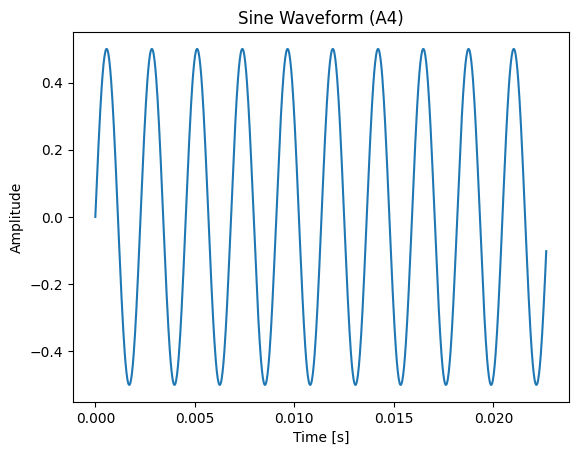

In [2]:
frequency = 440.0 # Frequency of the note (A4)
duration = 0.5 # Duration of the sound in seconds

t = np.linspace(0, duration, int(sample_rate * duration), endpoint=False) # Time array

waveform = 0.5 * np.sin(2 * np.pi * frequency * t) # Generate a sine wave at the specified frequency

plt.plot(t[:1000], waveform[:1000]) # Plot the first 1000 samples of the waveform
plt.title('Sine Waveform (A4)')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.show()

sd.play(waveform, sample_rate) # Play the generated sound
sd.wait() # Wait until the sound has finished playing

#### Musical Note Frequencies (A4 = 440 Hz)

| Note | Octave 1 | Octave 2 | Octave 3 | Octave 4 | Octave 5 | Octave 6 | Octave 7 | Octave 8 |
|------|----------|----------|----------|----------|----------|----------|----------|----------|
| C    | 32.70    | 65.41    | 130.81   | 261.63   | 523.25   | 1046.50  | 2093.00  | 4186.01  |
| C#   | 34.65    | 69.30    | 138.59   | 277.18   | 554.37   | 1108.73  | 2217.46  | —        |
| D    | 36.71    | 73.42    | 146.83   | 293.66   | 587.33   | 1174.66  | 2349.32  | —        |
| D#   | 38.89    | 77.78    | 155.56   | 311.13   | 622.25   | 1244.51  | 2489.02  | —        |
| E    | 41.20    | 82.41    | 164.81   | 329.63   | 659.25   | 1318.51  | 2637.02  | —        |
| F    | 43.65    | 87.31    | 174.61   | 349.23   | 698.46   | 1396.91  | 2793.83  | —        |
| F#   | 46.25    | 92.50    | 185.00   | 369.99   | 739.99   | 1479.98  | 2959.96  | —        |
| G    | 49.00    | 98.00    | 196.00   | 392.00   | 783.99   | 1567.98  | 3135.96  | —        |
| G#   | 51.91    | 103.83   | 207.65   | 415.30   | 830.61   | 1661.22  | 3322.44  | —        |
| A    | 55.00    | 110.00   | 220.00   | 440.00   | 880.00   | 1760.00  | 3520.00  | —        |
| A#   | 58.27    | 116.54   | 233.08   | 466.16   | 932.33   | 1864.66  | 3729.31  | —        |
| B    | 61.74    | 123.47   | 246.94   | 493.88   | 987.77   | 1975.53  | 3951.07  | —        |

Use these helper functions to hear the different notes! Choose a note and attach the octave number e.g. C#3

In [3]:
play_note_sine("C4", duration) # Play the note using the play_note_sine function from playback.py

In [4]:
play_note_square("A4", duration) # Play the note using the play_note_square function from playback.py

In [5]:
play_note_saw("A4", duration) # Play the note using the play_note_saw function from playback.py

### Playing a simple melody

A melody is a bunch of notes played in a specific order. In order to achieve this, we assign a duration to a note so the previous note stops before we start playing a new one.

With this in mind, let's play a melody starting at C4 and work our way to C5 while only playing the whole notes.

In [6]:
melody = {
    "C4": 0.5,
    "D4": 0.5,
    "E4": 0.5,
    "F4": 0.5,
    "G4": 0.5,
    "A4": 0.5,
    "B4": 0.5,
    "C5": 1.0
}

for note, duration in melody.items():
    play_note_sine(note, duration)

### Playing multiple sounds at the same time

A melody alone sounds flat, so we need to add flourish in the form of harmonies. A simple way to create harmonies is by playing chords underneath a melody.

The most commonly used types of chords are:
- major chords: root note + major third + perfect 5th
- minor chords: root note + minor third + perfect 5th
- major 7th chords: root note + major third + perfect 5th + 11th semitone from root
- minor 7th chords: root note + minor third + perfect 5th + 10th semitone from root
- dominant 7th chords: root note + major third + perfect 5th + 10th semitone from root
- power chords: root note + perfect 5th

Each of these types has a different notation to identify which type is asked to play. The notation is as follows: root note + abbreviated name of chord type e.g. major becomes maj.

Using a lookup table we can store the intervals between the notes, to always get the correct chord. These intervals are made up of semi-tones e.g. C4 -> C#4 is a semitone up, but so are E -> F.

In [7]:
{
  "major": [0, 4, 7],
  "minor": [0, 3, 7],
  "major7": [0, 4, 7, 11],
  "minor7": [0, 3, 7, 10],
  "dominant7": [0, 4, 7, 10],
  "power": [0, 7]
}

{'major': [0, 4, 7],
 'minor': [0, 3, 7],
 'major7': [0, 4, 7, 11],
 'minor7': [0, 3, 7, 10],
 'dominant7': [0, 4, 7, 10],
 'power': [0, 7]}

Lets say we want a C4maj chord. We take the chord symbol, split it into root note and chord type, then use the chord type to look up a set of intervals.

- parse_chord_symbol extracts the root like C3 and the chord quality like maj.
- note_to_midi converts the root note to a MIDI number.
- build_chord looks up the interval pattern for that chord type from chords_dict.
- It adds each interval to the root MIDI number to get the pitch of each chord tone.
- midi_to_note converts those resulting MIDI numbers back into note names.

So the chord notes are calculated by starting from the root pitch and adding the chord-specific intervals.

In [2]:
NOTES_ORDER = ["C", "C#", "D", "D#", "E", "F",
               "F#", "G", "G#", "A", "A#", "B"]

def parse_chord_symbol(symbol: str):
    """
    Parses a chord symbol (e.g., "C4maj", "A3min7") and returns the root note and chord type.
    """

    match = re.match(r"([A-G]#?)(\d)(.*)", symbol)
    if not match:
        raise ValueError("Invalid chord format")

    root_note = match.group(1) + match.group(2)
    chord_type = match.group(3)

    if chord_type == "maj":
        chord_type = "major"
    elif chord_type == "min":
        chord_type = "minor"
    elif chord_type == "min7":
        chord_type = "minor7"
    elif chord_type == "maj7":
        chord_type = "major7"
    elif chord_type == "dom7":
        chord_type = "dominant7"
    elif chord_type == "pow":
        chord_type = "power"

    return root_note, chord_type

def note_to_midi(note):
    name = note[:-1]
    octave = int(note[-1])
    return (octave + 1) * 12 + NOTES_ORDER.index(name)

def midi_to_note(midi):
    name = NOTES_ORDER[midi % 12]
    octave = midi // 12 - 1
    return f"{name}{octave}"

def build_chord(root, chord_type, chords_dict):
    root_midi = note_to_midi(root)
    intervals = chords_dict[chord_type]

    return [midi_to_note(root_midi + i) for i in intervals]

def chord_to_freqs(notes, notes_dict):
    return [notes_dict[n] for n in notes]

def generate_wave(freqs, duration, sr, type, add_tail=True):
    t = np.linspace(0, duration, int(sr * duration), False)
    wave = np.zeros_like(t)
    for f in freqs:
        if type == "sine":
            wave += np.sin(2 * np.pi * f * t)
        elif type == "square":
            wave += np.sign(np.sin(2 * np.pi * f * t))
        elif type == "sawtooth":
            wave += 2 * (t * f - np.floor(0.5 + t * f))
    wave /= len(freqs)
    wave = apply_envelope(wave, sr, add_tail=add_tail) # Apply an envelope to the wave to prevent clicks
    wave /= np.max(np.abs(wave))
    return wave.astype(np.float32)

All that's left is to play chords!

In [3]:
chord_progression = [
        ("C3maj", 2.0),
        ("F3maj", 1.5),
        ("G3maj", 1.0),
        ("C3maj", 2.0),
    ]

play_chords(chord_progression, type="sine")

### Playing a song

Now that we can play melodies and chords, it's time to combine the two and play a little piece. But how are we going to do that? Well we do this the exact same way we make the chords. But instead of mashing all the notes together into a single waveform, we mash the waveform of the chords with the wavefrom of the melody, so the waveforms can be percieved seperately.

Ps. check playback piece for the code!